<div class="alert alert-block alert-info"><font color='blue', size="8"><center><b>
PROSPER + Openserver + Phyton
</font></div>

<font size="5"><center><b>
Probabilistic Analysis for Gas Well Model (PROSPER)
 <br></font>

Last update: 11 01 2026 (dd mm yy)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.gridspec as gridspec

import seaborn as sns
import scipy.stats as stats

import time

from collections import defaultdict       # library to create dictionarie variables
from openserver import OpenServer         # Library to connect Python with PROSPER using Openserver API
from IPython.display import Javascript    # run multiple cells at once
from IPython.display import display_html  # Display Multiple Data Frames in one cell
from IPython.display import clear_output  # Clear output cell

from IPython.display import display, HTML, Markdown
display(HTML("<style>.cm-s-ipython span.cm-comment { color: blue; }</style>")) # Comments color = blue

import ipywidgets as widgets

## Costume FUNCTIONS: Functions_Probabilistic_Analysis_Gas_Well_Model.ipynb
import import_ipynb # Library to call costume functions

import Functions_Probabilistic_Analysis_Gas_Well_Model as my_Func

## 2. Input Variables

Set input Variables as distributions or constants <br>

Specify distribution type: Normal, Uniform, Constant. <br>
If Dist_Type = 'Constant', one single value (val_Const) will be sent to PROSPER model. <br> <br>
low and high values are used for Uniform distribution and also to truncate the Normal distribution (Example: prevent negative permeability). <br>

Units must be checked on PROSPER model

In [3]:
Input_var_dict ={}

var_label, Dist_Type = 'Reservoir Pressure','Normal' 
low, high,val_mean, val_SD, val_Const = 400, 3000, 2000, 400, 2500
Input_var_dict['Pr'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Permeability','Normal' 
low, high,val_mean, val_SD, val_Const = 0.001, 100,10, 5,25 
Input_var_dict['k'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Reservoir Height', 'Uniform' 
low, high,val_mean, val_SD, val_Const = 50, 100,50, 6, 20 
Input_var_dict['h'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

### PERFORATION INTERVAL: Max limit must be equal or less than Reservoir Height
### Iterations where Perforation interval is more than Reservoir Height the Perforation interval will be set equal to reservoir height
var_label, Dist_Type = 'Perforation Interval','Normal'
low, high,val_mean, val_SD, val_Const = 5, 100, 44, 6, 20
Input_var_dict['Perf'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Skin', 'Normal'
low, high,val_mean, val_SD, val_Const = -5, 50, 38, 10, 2 
Input_var_dict['S'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Water-Gas Rate', 'Uniform'
low, high,val_mean, val_SD, val_Const  = 0, 500, 300, 20, 20 #limits to truncate distribution
Input_var_dict['WGR'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Drainage Area', 'Uniform'
low, high,val_mean, val_SD, val_Const  = 500, 800, 300, 20, 701 #limits to truncate distribution
Input_var_dict['DA'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]

var_label, Dist_Type = 'Top Node Pressure', 'Uniform'
low, high,val_mean, val_SD, val_Const  = 100, 1000, 300, 20, 300 #limits to truncate distribution
Input_var_dict['Top_Press'] = [low, high, val_mean, val_SD, val_Const, Dist_Type, var_label]


# -> display input as DataFrame
my_Func.Input_Variables_DF(Input_var_dict)

,Pr,k,h,Perf,S,WGR,DA,Top_Press
Low,400,0.001,50,5,-5,0,500,100
High,3000,100,100,100,50,500,800,1000
Mean,2000,10,50,44,38,300,300,300
SD,400,5,6,6,10,20,20,20
Constant,2500,25,20,20,2,20,701,300
Distribution,Normal,Normal,Uniform,Normal,Normal,Uniform,Uniform,Uniform
Variable,Reservoir Pressure,Permeability,Reservoir Height,Perforation Interval,Skin,Water-Gas Rate,Drainage Area,Top Node Pressure


## 3. Plot distribution for input variables


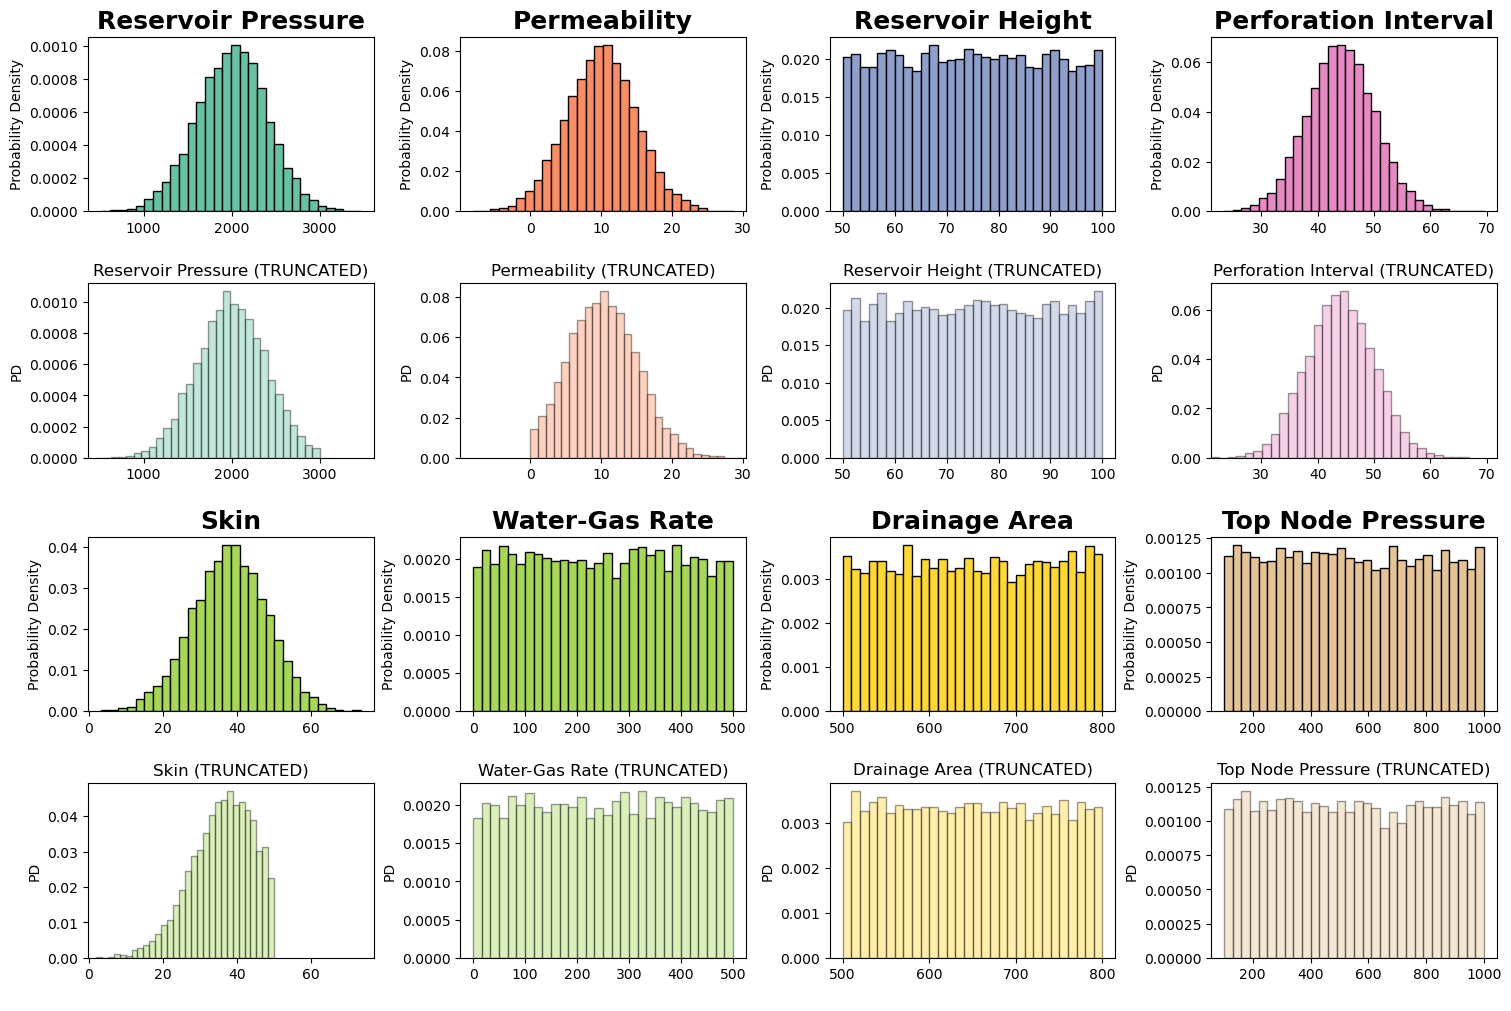

In [4]:
my_Func.Plot_Input_func(Input_var_dict)

## 4. Import production test history data 
Production test data will be used to validate/compare results from well model (WHP/Qg production test vs well model results). <br>
Choke values from production test can be used on well model calculations. <br>
If no production history is available, set use_PDP_hist = False.  <br>
The production history must on .csv file

In [5]:
use_PDP_hist = False

if use_PDP_hist == True:

    df_PDP_hist = pd.read_csv ('comp_PDP_data.csv', delimiter=',')
    df_PDP_hist['Gas'] = df_PDP_hist['Gas'].div(1000)

    indexAge = df_PDP_hist[ (df_PDP_hist['Gas'] >= 3)].index
    df_PDP_hist.drop(indexAge , inplace=True)

    df_PDP_hist.describe().round(2) # Show DataFrame
else:
    df_PDP_hist = pd.DataFrame()

### Well Choke input

Specify if chokes from production test (history) are used as input for PROSPER model.

In [6]:
use_PT_choke = False 

if use_PT_choke == True:
    CK_PT_list = df_PDP_hist['Choke'].unique() # Extract Choke List from production test (history) data
    print('Chokes from Production Test (history) = ', CK_PT_list)

Choke_list = [22,24,26,28,36,50,64] # Specify choke values to be used on well model (PROSPER). 
print('Choke list from user = ', Choke_list)

if use_PT_choke == True: Choke_list = CK_PT_list
print('Chokes to be used on PROSPER = ', Choke_list)

Choke list from user =  [22, 24, 26, 28, 36, 50, 64]
Chokes to be used on PROSPER =  [22, 24, 26, 28, 36, 50, 64]


<div class="alert alert-success"><font color='blue'>
    
## 5. VLP correlation
Specify if VLP correlation will be used as variable for each iteration
***
</font>

</div>

If VLP_corr_status = True, each iteration will have different VLP correlation. <br>

Set VLP_corr_GREmod_PE4=False to exclude Correlations: GREmodifiedbyPE and PetroleumExperts4. <br>
These correlations take longer time to calculate. 

In [7]:
VLP_corr_status = True
VLP_corr_GREmod_PE4 = False

VLP_index_list = [0,1,2,4,5,8,9,10,11,12,14,18,19]    
VLP_names = ['DunsandRosModified', 'HagedornBrown', 'FancherBrown', 'MukerjeeBrill', 'BeggsandBrill', \
                 'PetroleumExperts', 'Orkiszewski', 'PetroleumExperts2', 'DunsandRosOriginal', 'PetroleumExperts3', \
                 'GREmodifiedbyPE', 'PetroleumExperts4', 'Hydro3P']

if VLP_corr_GREmod_PE4 == False:
    VLP_index_list.remove(14),    VLP_index_list.remove(18)
    VLP_names.remove('GREmodifiedbyPE'),    VLP_names.remove('PetroleumExperts4')

print('Total number of correlations = ',len(VLP_index_list), '\n')
for xii, element in enumerate(VLP_names): print('Index:', VLP_index_list[xii], VLP_names[xii] )

Total number of correlations =  11 

Index: 0 DunsandRosModified
Index: 1 HagedornBrown
Index: 2 FancherBrown
Index: 4 MukerjeeBrill
Index: 5 BeggsandBrill
Index: 8 PetroleumExperts
Index: 9 Orkiszewski
Index: 10 PetroleumExperts2
Index: 11 DunsandRosOriginal
Index: 12 PetroleumExperts3
Index: 19 Hydro3P


<div class="alert alert-success"><font color='blue'>
 
## 6. Start Calculations for Sensitivity Analysis

1. Generate input variables based on distributions
2. Send the input variables from Jupyter Notebook to Well model (PROSPER)
3. Update Well IPR
4. Calculate Well Model (solve for VLP and IPR)
5. Import results from Well Model (PROSPER) to Jupyter Notebook. Results are saved inside dictionary variables
    
***
</font></div>

In [ ]:
start = time.time()

Results_display_Type = 'Only Text' # Faster
#Results_display_Type = 'Plots + DF'

## Create Dictionaries to fill inputs and results. Everytime this cell is run the dictionary elements are deleted
# dictionary to save VLP and IPR Curves # dictionary to save Inputs/Solutions
my_dict, my_dict_input_vals = defaultdict(list), defaultdict(list)     

## Check if OpenServer Lic is open
if 'c' in locals(): print('c is active') 
else: c = OpenServer()
c.connect()

iteraciones = 2500 # -> Set iterations

i = 0
while i < iteraciones:
        
    Rand_val, my_dict_input_vals = Generate_rand_val('Pr',Input_var_dict,my_dict_input_vals)                ## Reservoir Pressure
    c.DoSet('PROSPER.SIN.IPR.Single.Pres', Rand_val) # Change variable on PROSPER
    
    Rand_val, my_dict_input_vals = Generate_rand_val('DA',Input_var_dict,my_dict_input_vals)                ### DRAINAGE AREA 
    c.DoSet('PROSPER.SIN.IPR.Single.Drainage', Rand_val) # Change variable on PROSPER    
    
    Rand_val, my_dict_input_vals = Generate_rand_val('k',Input_var_dict,my_dict_input_vals)                 ### PERMEABILITY
    c.DoSet('PROSPER.SIN.IPR.Single.ResPerm', Rand_val) # Change variable on PROSPER       
    
    Rand_val, my_dict_input_vals = Generate_rand_val('h',Input_var_dict,my_dict_input_vals)                 ### Reservoir Height 
    c.DoSet('PROSPER.SIN.IPR.Single.Thickness', Rand_val) # Change variable on PROSPER     
    #test_val = Rand_val
    
    Rand_val, my_dict_input_vals = Generate_rand_val('Perf',Input_var_dict,my_dict_input_vals, Rand_val)    ## Perforation Interval 
    c.DoSet('PROSPER.SIN.IPR.Single.PerfInt', Rand_val) # Change variable on PROSPER      
   
    Rand_val, my_dict_input_vals = Generate_rand_val('S',Input_var_dict,my_dict_input_vals)                 ### SKIN 
    c.DoSet('PROSPER.SIN.IPR.Single.Skin', Rand_val) # Change variable on PROSPER    
 
    Rand_val, my_dict_input_vals = Generate_rand_val('WGR',Input_var_dict,my_dict_input_vals)               ### WGR 
    c.DoSet('PROSPER.SIN.IPR.Single.WGR', Rand_val) # Change variable on PROSPER  
    c.DoSet('PROSPER.ANL.SYS.WGR', Rand_val) # Change variable on PROSPER  
    
    Rand_val, my_dict_input_vals = Generate_rand_val('Top_Press',Input_var_dict,my_dict_input_vals)         ### WGR 
    c.DoSet('PROSPER.ANL.SYS.Pres', Rand_val) # Change variable on PROSPER  

  
    ### VLP Correlation ###
    if VLP_corr_status == True:
        VLP_Index_sample = np.random.choice(VLP_index_list, 1)
        
        
        index_vlp = VLP_index_list.index(VLP_Index_sample)
        VLP_Index_sample_Name = VLP_names[index_vlp]
        VLP_Index_sample_Name =[VLP_Index_sample_Name]
        
        my_dict_input_vals['VLP_Corr'].extend(VLP_Index_sample)
        my_dict_input_vals['VLP_Corr_Name'].extend(VLP_Index_sample_Name)
        
        c.DoSet('PROSPER.ANL.SYS.TubingLabel', VLP_Index_sample)
          
    else:
        my_dict_input_vals['VLP_Corr'].extend(100)
        my_dict_input_vals['VLP_Corr_Name'].extend(100)
        

        
    ### WELL CHOKE ###
    Choke = np.random.choice(Choke_list, 1)      
    my_dict_input_vals['Choke'].extend(Choke)         
    c.DoSet('PROSPER.SIN.EQP.Surf.Data[1].ID', Choke/64)
    
    c.DoCmd('PROSPER.IPR.CALC') # Calculate new IPR ### Required after changing IPR variables ###
     
    c.DoCmd('PROSPER.ANL.SYS.CALC') # Calculate Well model

    ## Extract Solution from PROSPER. Some variable strings change based on PROSPER version
    Gas_Curve = c.DoGet('PROSPER.OUT.SYS.Results[0].GasRate[$]')
    IPR_Curve = c.DoGet('PROSPER.OUT.SYS.Results[0].IPRpres[$]')
    VLP_Curve = c.DoGet('PROSPER.OUT.SYS.Results[0].VLPpres[$]')
    
    Gas_Sol = c.DoGet('PROSPER.OUT.SYS.Results[0].Sol.GasRate')
    BHP_Sol = c.DoGet('PROSPER.OUT.SYS.Results[0].Sol.BHP')
    
    #WHP_Sol = c.DoGet('PROSPER.OUT.SYS.SOL[0].WHP')  
    WHP_Sol = c.DoGet('PROSPER.OUT.SYS.Results[0].Sol.WHPressure') 
    
    #Water_Sol = c.DoGet('PROSPER.OUT.SYS.SOL[0].QWAT')
    Water_Sol = c.DoGet('PROSPER.OUT.SYS.Results[0].Sol.WatRate')
    
    Gas_AOF = c.DoGet('Prosper.SIN.IPR.Single.AOF')
    
    
    if Gas_Sol > 1000000: Gas_Sol,BHP_Sol,WHP_Sol,Water_Sol = 0,0,0,0
        
    # Add solutions to dictionary
    my_dict_input_vals['Sol_Gas'].extend([Gas_Sol]),    my_dict_input_vals['FBHP'].extend([BHP_Sol])
    my_dict_input_vals['Sol_WHP'].extend([WHP_Sol]),    my_dict_input_vals['Sol_Water'].extend([Water_Sol])
        
    ## -> Add  VLP + IPR to Dictionary
    Curves_n = len(Gas_Curve)
    my_dict['Iteration'].extend([i]*Curves_n)
    my_dict['Gas Rate'].extend(Gas_Curve)
    my_dict['IPR_Pressure'].extend(IPR_Curve),    my_dict['VLP_Pressure'].extend(VLP_Curve)
    
    # -> Print values while iterating
    
    if Gas_Sol > 0: print_input_and_solutions(Results_display_Type,i,my_dict_input_vals,VLP_Index_sample,VLP_Index_sample_Name,
                                 Choke, Gas_Sol, BHP_Sol, WHP_Sol,Water_Sol, Gas_AOF,iteraciones)

    i = i + 1
    
c.disconnect

print('Total Time (seconds): ', time.time() - start) # time in seconds


<div class="alert alert-success">
<font color='blue'>
    
# 7. Convert dictionaries to Data Frames + save data as .csv files
    
***
</font></div>

In [ ]:
df_VLP_IPR = pd.DataFrame(my_dict)                 # VLP and IPR

df_Input_All = pd.DataFrame(my_dict_input_vals)    # Input for all iterations

 # Input for iteration with solution 
df_Input_sol = df_Input_All.copy()
df_Input_sol = df_Input_sol[df_Input_sol['Sol_Gas'] > 0]
df_Input_sol = df_Input_sol.reset_index(drop=True)

# Input for iterations without solution
df_Input_No_sol = df_Input_All.copy()
df_Input_No_sol = df_Input_No_sol[df_Input_No_sol['Sol_Gas'] == 0]
df_Input_No_sol = df_Input_No_sol.reset_index(drop=True)

### Save Data Frames as .csv ###
df_VLP_IPR.to_csv("VLP_IPR.csv",index=False)

df_Input_All.to_csv("Input_ALL_solutiones.csv",index=False)
df_Input_sol.to_csv("Input_with_solutions.csv",index=False)
df_Input_No_sol.to_csv("Input_No_solutions.csv",index=False)



<div class="alert alert-success">
<font color='blue'>
    
## 8. IMPORT saved .csv files (run the next cell)
This will allow to continue working with saved results/inputs without running PROSPER again. <br>
It is still requiered to run cell 1 (import libraries)
    
***
</font></div>


In [8]:
df_VLP_IPR = pd.read_csv ('VLP_IPR.csv')                    # VLP and IPR

df_Input_All = pd.read_csv ('Input_ALL_solutiones.csv')     # Input for all iterations
df_Input_sol = pd.read_csv ('Input_with_solutions.csv')     # Input for iteration with solution 
df_Input_No_sol = pd.read_csv ('Input_No_solutions.csv')    # Input for iterations without solution

iter = df_Input_All.shape[0]
i = iter
print('No. Iterations = ',iter)

No. Iterations =  2500


<div class="alert alert-success">
<font color='blue'>
    
## 9. Check Info, head values and Statistics
    
***
</font>

</div>

In [9]:
Iterations_No_Sol, Iterations_with_Sol = (df_Input_All['Sol_Gas'] == 0).sum(), (df_Input_All['Sol_Gas'] > 0).sum()

perc_No_Sol = Iterations_No_Sol/(Iterations_No_Sol+Iterations_with_Sol)*100
perc_with_Sol = 100 - perc_No_Sol

str_1 =' *NO Solution = ' + str(Iterations_No_Sol) + ' ('+ str(perc_No_Sol.round(2)) + '%)'
str_2 =' *With Solution = ' + str(Iterations_with_Sol) + ' ('+ str(perc_with_Sol.round(2)) + '%)'

display(Markdown(f"####  Total Iterations: {i}")), display(Markdown(f"#### {str_1}")), display(Markdown(f"#### {str_2}"));

####  Total Iterations: 2500

####  *NO Solution = 1244 (49.76%)

####  *With Solution = 1256 (50.24%)

In [10]:
my_Func.Display_Info_Head_Stats_DF('Info + Values - All Iterations', df_Input_All,10)
my_Func.Display_Info_Head_Stats_DF('Info + Values - Solutions', df_Input_sol,5)
my_Func.Display_Info_Head_Stats_DF('Info + Values - NO Solutions', df_Input_No_sol,5)

## Info + Values - All Iterations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pr             2500 non-null   float64
 1   DA             2500 non-null   float64
 2   k              2500 non-null   float64
 3   h              2500 non-null   float64
 4   Perf           2500 non-null   float64
 5   S              2500 non-null   float64
 6   WGR            2500 non-null   float64
 7   Top_Press      2500 non-null   float64
 8   VLP_Corr       2500 non-null   int64  
 9   VLP_Corr_Name  2500 non-null   object 
 10  Choke          2500 non-null   int64  
 11  Sol_Gas        2500 non-null   float64
 12  FBHP           2500 non-null   float64
 13  Sol_WHP        2500 non-null   float64
 14  Sol_Water      2500 non-null   float64
dtypes: float64(12), int64(2), object(1)
memory usage: 293.1+ KB


,Pr,DA,k,h,Perf,S,WGR,Top_Press,VLP_Corr,VLP_Corr_Name,Choke,Sol_Gas,FBHP,Sol_WHP,Sol_Water
0,2368.2,611.3,14.0,90.9,37.0,45.8,135.0,969.6,0,DunsandRosModified,22,1.74,2299.37,1158.79,235.46
1,2189.2,709.3,15.7,52.5,52.5,46.0,390.4,589.1,1,HagedornBrown,22,1.05,2122.17,845.54,409.33
2,2531.6,678.2,16.6,61.2,35.1,36.2,212.0,570.0,11,DunsandRosOriginal,28,2.88,2419.40,1119.56,610.54
3,2230.4,578.2,14.9,74.9,46.1,42.7,169.2,120.8,12,PetroleumExperts3,20,1.77,2152.97,1221.30,299.69
4,2818.1,655.8,29.0,67.5,49.9,43.6,73.3,643.3,0,DunsandRosModified,64,13.07,2515.48,834.91,958.02
5,2453.0,621.9,23.3,72.0,43.7,42.8,263.9,318.3,1,HagedornBrown,28,2.48,2384.65,1033.20,653.23
6,2242.0,706.5,19.9,93.1,41.4,15.3,283.2,589.0,19,Hydro3P,36,0.00,0.00,0.00,0.00
7,2324.0,641.3,21.7,58.3,42.7,40.3,238.0,646.4,10,PetroleumExperts2,26,2.44,2236.44,1147.39,581.34
8,1688.1,568.9,12.6,87.9,41.0,31.8,338.4,331.9,8,PetroleumExperts,24,1.17,1640.49,717.49,394.96
9,1439.2,620.4,23.0,99.3,44.2,46.9,199.3,587.8,10,PetroleumExperts2,26,1.27,1398.72,699.27,253.79


### Statistics 

,Pr,DA,k,h,Perf,S,WGR,Top_Press,VLP_Corr,VLP_Corr_Name,Choke,Sol_Gas,FBHP,Sol_WHP,Sol_Water
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,NaN,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1998.20,650.34,19.95,75.24,44.04,35.88,252.60,558.45,7.29,NaN,33.89,1.97,977.45,444.33,309.65
std,397.65,85.98,5.06,14.54,6.02,8.33,145.65,260.73,5.47,NaN,14.63,2.71,1007.97,491.91,474.39
min,536.80,500.10,5.40,50.00,23.60,-0.29,0.03,100.30,0.00,NaN,20.00,0.00,0.00,0.00,0.00
10%,1478.03,532.99,13.49,54.80,36.39,24.80,53.68,191.73,1.00,NaN,20.00,0.00,0.00,0.00,0.00
20%,1649.70,563.66,15.70,60.08,38.90,28.80,98.78,287.24,2.00,NaN,22.00,0.00,0.00,0.00,0.00
40%,1894.82,620.10,18.70,70.10,42.56,34.20,202.86,472.30,5.00,NaN,26.00,0.00,0.00,0.00,0.00
50%,2014.95,649.25,20.00,75.60,44.00,36.60,251.40,563.70,8.00,NaN,28.00,0.15,994.70,255.75,4.70
60%,2117.30,676.48,21.20,80.90,45.70,38.94,305.90,653.06,9.00,NaN,28.00,1.85,1621.42,621.36,189.26
80%,2336.36,739.70,24.00,90.30,49.20,43.40,402.76,831.52,11.00,NaN,50.00,3.72,2046.17,943.60,596.14


...

## Info + Values - NO Solutions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1244 entries, 0 to 1243
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pr             1244 non-null   float64
 1   DA             1244 non-null   float64
 2   k              1244 non-null   float64
 3   h              1244 non-null   float64
 4   Perf           1244 non-null   float64
 5   S              1244 non-null   float64
 6   WGR            1244 non-null   float64
 7   Top_Press      1244 non-null   float64
 8   VLP_Corr       1244 non-null   int64  
 9   VLP_Corr_Name  1244 non-null   object 
 10  Choke          1244 non-null   int64  
 11  Sol_Gas        1244 non-null   float64
 12  FBHP           1244 non-null   float64
 13  Sol_WHP        1244 non-null   float64
 14  Sol_Water      1244 non-null   float64
dtypes: float64(12), int64(2), object(1)
memory usage: 145.9+ KB


,Pr,DA,k,h,Perf,S,WGR,Top_Press,VLP_Corr,VLP_Corr_Name,Choke,Sol_Gas,FBHP,Sol_WHP,Sol_Water
0,2242.0,706.5,19.9,93.1,41.4,15.3,283.2,589.0,19,Hydro3P,36,0.0,0.0,0.0,0.0
1,847.5,635.3,24.3,64.7,44.7,39.8,445.6,451.5,2,FancherBrown,50,0.0,0.0,0.0,0.0
2,1820.4,537.0,24.2,76.7,46.3,36.3,169.0,635.7,10,PetroleumExperts2,22,0.0,0.0,0.0,0.0
3,1669.8,722.5,12.6,75.3,37.4,32.2,321.2,782.6,5,BeggsandBrill,50,0.0,0.0,0.0,0.0
4,1543.8,703.4,30.7,91.1,46.1,43.7,181.4,813.9,4,MukerjeeBrill,26,0.0,0.0,0.0,0.0
5,1854.1,561.2,22.0,79.5,50.7,39.8,430.9,704.9,10,PetroleumExperts2,26,0.0,0.0,0.0,0.0


### Statistics 

,Pr,DA,k,h,Perf,S,WGR,Top_Press,VLP_Corr,VLP_Corr_Name,Choke,Sol_Gas,FBHP,Sol_WHP,Sol_Water
count,1244.00,1244.00,1244.00,1244.00,1244.00,1244.00,1244.00,1244.00,1244.00,NaN,1244.00,1244.0,1244.0,1244.0,1244.0
mean,1916.99,650.46,20.56,76.28,44.02,35.26,312.35,640.25,7.68,NaN,29.13,0.0,0.0,0.0,0.0
std,404.53,86.39,5.09,14.50,6.11,8.45,127.67,248.86,5.38,NaN,11.90,0.0,0.0,0.0,0.0
min,536.80,500.60,5.70,50.00,23.60,-0.29,0.51,103.40,0.00,NaN,20.00,0.0,0.0,0.0,0.0
10%,1406.80,529.76,13.90,55.53,36.30,24.30,123.80,257.66,1.00,NaN,20.00,0.0,0.0,0.0,0.0
20%,1570.18,560.54,16.40,61.20,38.76,28.00,186.94,394.08,4.00,NaN,22.00,0.0,0.0,0.0,0.0
40%,1796.42,621.12,19.22,71.60,42.42,33.50,283.42,595.32,5.00,NaN,24.00,0.0,0.0,0.0,0.0
50%,1920.70,649.85,20.50,77.60,44.15,35.90,332.25,686.40,8.00,NaN,24.00,0.0,0.0,0.0,0.0
60%,2039.50,680.16,21.80,82.26,45.80,38.20,370.38,753.92,9.00,NaN,26.00,0.0,0.0,0.0,0.0
80%,2262.02,738.52,24.60,91.14,49.40,42.94,442.22,880.84,11.00,NaN,36.00,0.0,0.0,0.0,0.0


#### Check if perforation (Perf) values are less than reservoir thickness (h). Minimum value must be 0 (h = Perf).

In [11]:
h_perf_S = df_Input_All['h'] - df_Input_All['Perf'] # -> operation results on a Series
h_perf_df = h_perf_S.to_frame(name='Res Height - Perfs')
display(h_perf_df.describe().T)


,count,mean,std,min,25%,50%,75%,max
Res Height - Perfs,2500.0,31.19488,15.69996,0.0,18.075,31.0,44.2,68.7


<div class="alert alert-success"> <font color='blue'>

## 10. ANALYZE RESULTS -  PRESSURE/GAS RATE @ Solution Node
***
</font> </div>

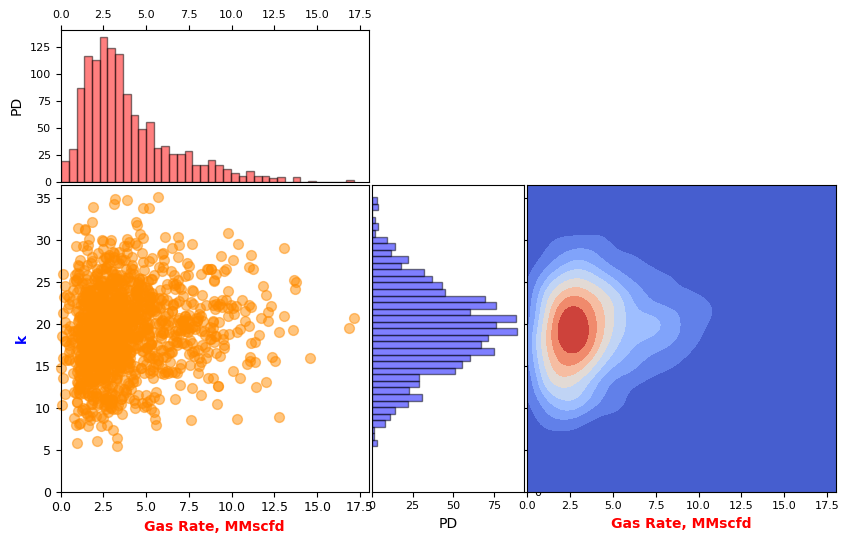

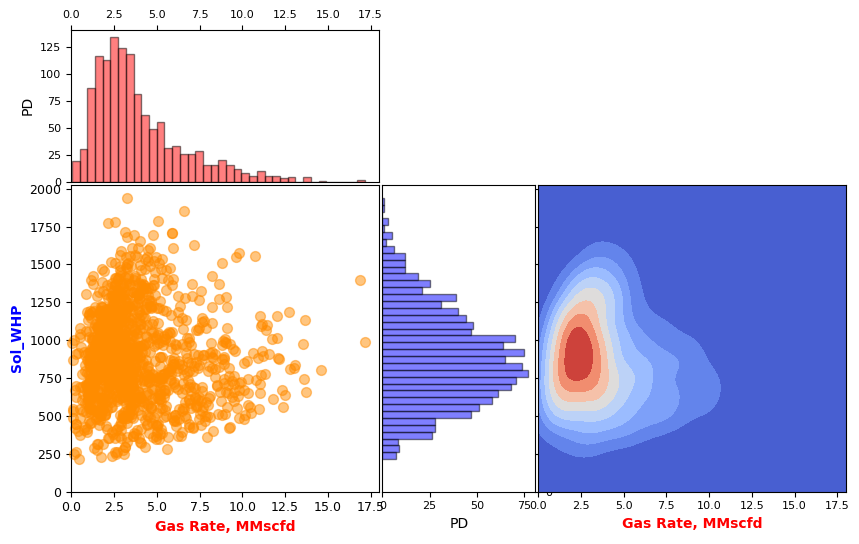

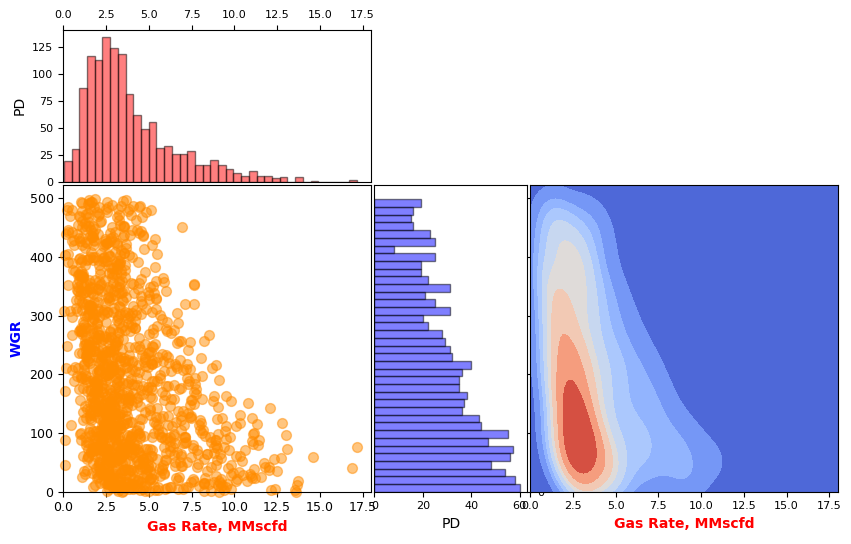

In [12]:
my_Func.Gen_Scatter_Density_Distribution(df_Input_sol,'Sol_Gas', 'k','Density')
my_Func.Gen_Scatter_Density_Distribution(df_Input_sol,'Sol_Gas', 'Sol_WHP','Scatter')
my_Func.Gen_Scatter_Density_Distribution(df_Input_sol,'Sol_Gas', 'WGR','Scatter')

<div class="alert alert-success">
<font color='blue'>

    
## 11. Analysis VLP correlations

    
***
</font> </div>

## VLP Correlations

,VLP_Index,Corr_Name,VLP_Val_Sum,Color
0,0,DunsandRosModified,132,
1,1,HagedornBrown,105,
2,2,FancherBrown,227,
3,4,MukerjeeBrill,84,
4,5,BeggsandBrill,54,
5,8,PetroleumExperts,134,
6,9,Orkiszewski,71,
7,10,PetroleumExperts2,148,
8,11,DunsandRosOriginal,64,
9,12,PetroleumExperts3,128,


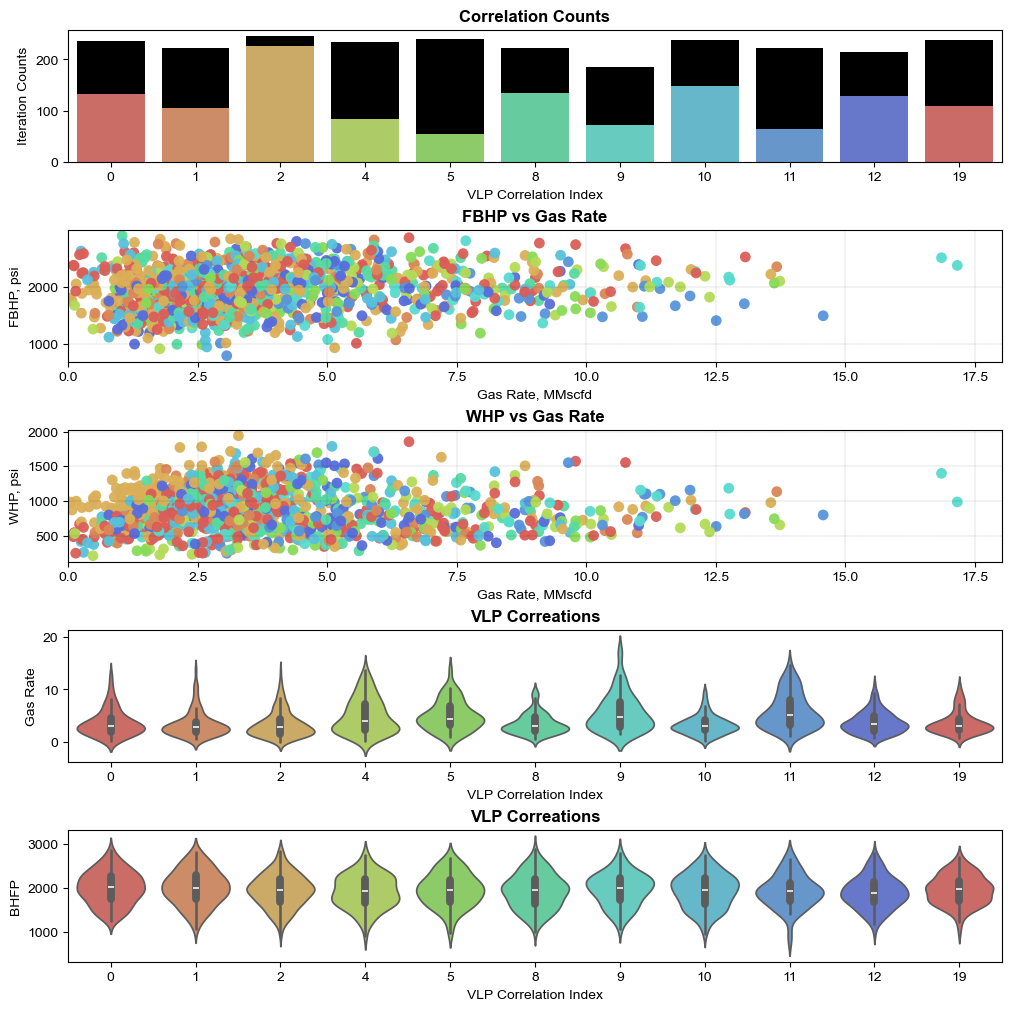

In [13]:
my_Func.VLP_Analysis(VLP_names,VLP_index_list,df_Input_sol,df_Input_All)


   
## Density maps for VLP Correlations


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pr             1256 non-null   float64
 1   DA             1256 non-null   float64
 2   k              1256 non-null   float64
 3   h              1256 non-null   float64
 4   Perf           1256 non-null   float64
 5   S              1256 non-null   float64
 6   WGR            1256 non-null   float64
 7   Top_Press      1256 non-null   float64
 8   VLP_Corr       1256 non-null   int64  
 9   VLP_Corr_Name  1256 non-null   object 
 10  Choke          1256 non-null   int64  
 11  Sol_Gas        1256 non-null   float64
 12  FBHP           1256 non-null   float64
 13  Sol_WHP        1256 non-null   float64
 14  Sol_Water      1256 non-null   float64
dtypes: float64(12), int64(2), object(1)
memory usage: 147.3+ KB


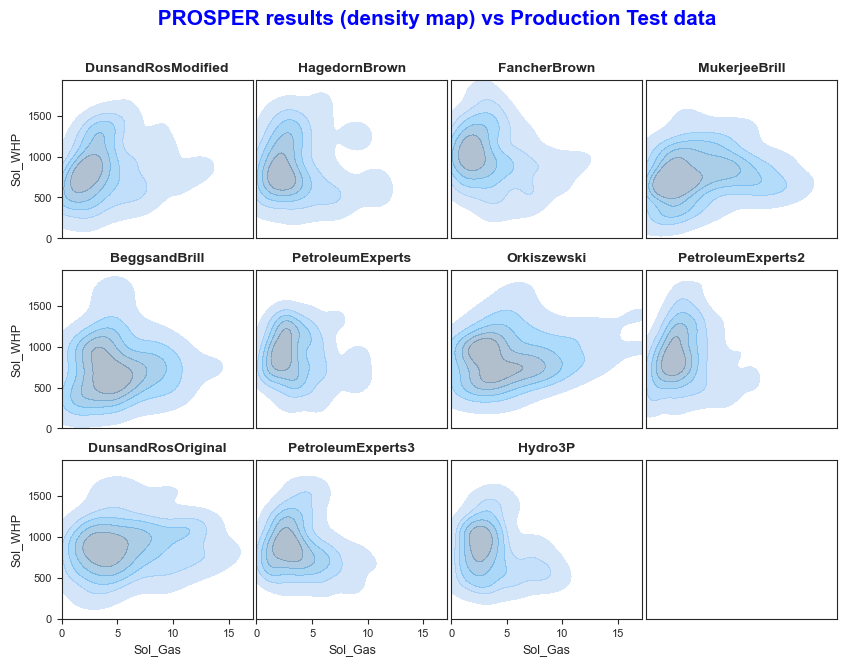

In [14]:
df_Input_sol.info()
my_Func.Density_Plot_VLP_corr('Sol_WHP', 'Sol_Gas', VLP_index_list,VLP_names,df_Input_sol,df_PDP_hist)

<div class="alert alert-success">
<font color='black'>
    
# OUTLIERS 
  
Based on above distributions delete outliers. <br>
Specify low and high percentile to drop rows outside the limits
</font>
</div>

In [15]:
Max_P_to_drop_vals = 98
Min_P_to_drop_vals = 2

Qg_mean = df_Input_sol['Sol_Gas'].mean()
P_mean = df_Input_sol['FBHP'].mean()

pval_to_drop = np.percentile(df_Input_sol['Sol_Gas'], Max_P_to_drop_vals)

df_Input_sol.drop(df_Input_sol[df_Input_sol.Sol_Gas > pval_to_drop].index, inplace=True)

pval_to_drop = np.percentile(df_Input_sol['Sol_Gas'], Min_P_to_drop_vals)

df_Input_sol.drop(df_Input_sol[df_Input_sol.Sol_Gas < pval_to_drop].index, inplace=True)


### Compare Stadistics ###
dfS_col_names =df_Input_All.columns.tolist()
dfS_In_col_names =df_Input_sol.columns.tolist()

df1 = pd.DataFrame(df_Input_All.describe(), columns=dfS_col_names)
df2 = pd.DataFrame(df_Input_sol.describe(), columns=dfS_In_col_names)

df1_styler = df1.style.set_table_attributes("style='display:inline'").set_caption('All Iteration Results')
df2_styler = df2.style.set_table_attributes("style='display:inline'").set_caption('Iterations with Solution')

display_html(df1_styler._repr_html_() + df2_styler._repr_html_(), raw=True)

p = np.percentile(df_Input_sol['Sol_Gas'], 1)
print ("Percentile 1 = ", p)
p = np.percentile(df_Input_sol['Sol_Gas'], 95)
print ("Percentile 95 = ", p)

,Pr,DA,k,h,Perf,S,WGR,Top_Press,VLP_Corr,VLP_Corr_Name,Choke,Sol_Gas,FBHP,Sol_WHP,Sol_Water
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,nan,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1998.199800,650.337640,19.949920,75.235040,44.040160,35.879364,252.604601,558.454440,7.288000,nan,33.888000,1.969812,977.449746,444.334669,309.648991
std,397.648793,85.980993,5.057126,14.535287,6.022261,8.334536,145.649775,260.727956,5.473083,nan,14.625328,2.708192,1007.970251,491.907940,474.391275
min,536.800000,500.100000,5.400000,50.000000,23.600000,-0.289700,0.028800,100.300000,0.000000,nan,20.000000,0.000000,0.000000,0.000000,0.000000
25%,1712.275000,578.025000,16.600000,62.500000,40.000000,30.500000,125.025000,335.075000,2.000000,nan,22.000000,0.000000,0.000000,0.000000,0.000000
50%,2014.950000,649.250000,20.000000,75.600000,44.000000,36.600000,251.400000,563.700000,8.000000,nan,28.000000,0.147303,994.696320,255.752884,4.703644
75%,2270.250000,722.075000,23.200000,87.900000,48.300000,42.200000,377.300000,784.900000,11.000000,nan,50.000000,3.227838,1954.357391,863.263351,467.326958
max,2967.200000,799.900000,37.500000,100.000000,67.400000,50.000000,499.700000,999.600000,19.000000,nan,64.000000,17.162739,2886.434570,1940.273315,3139.603271
,Pr,DA,k,h,Perf,S,WGR,Top_Press,VLP_Corr,VLP_Corr_Name,Choke,Sol_Gas,FBHP,Sol_WHP,Sol_Water
count,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,nan,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000


Percentile 1 =  0.82826817972
Percentile 95 =  8.8174280164


<div class="alert alert-success">
<font color='blue'>
    
## 7. ANALYZE INPUT VALUES

***
</font>
</div>


## Plot Distribution for input variables (Iterations with Solution)

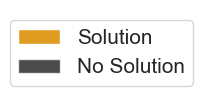

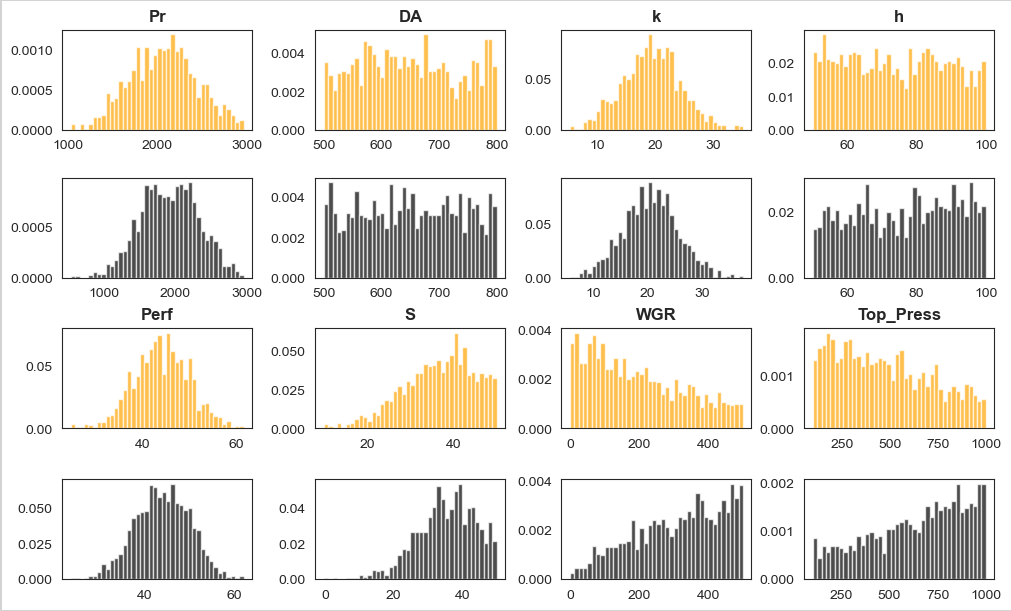

In [16]:
# -> DataFrame with solutions, df without solutions, Distribution Bins, fig height, fig width
my_Func.Plot_Distributions_Inputs(df_Input_sol,df_Input_No_sol,40,6,10) 

## Plot Distributions with solution and without solution next to each other

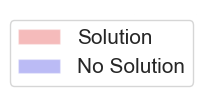

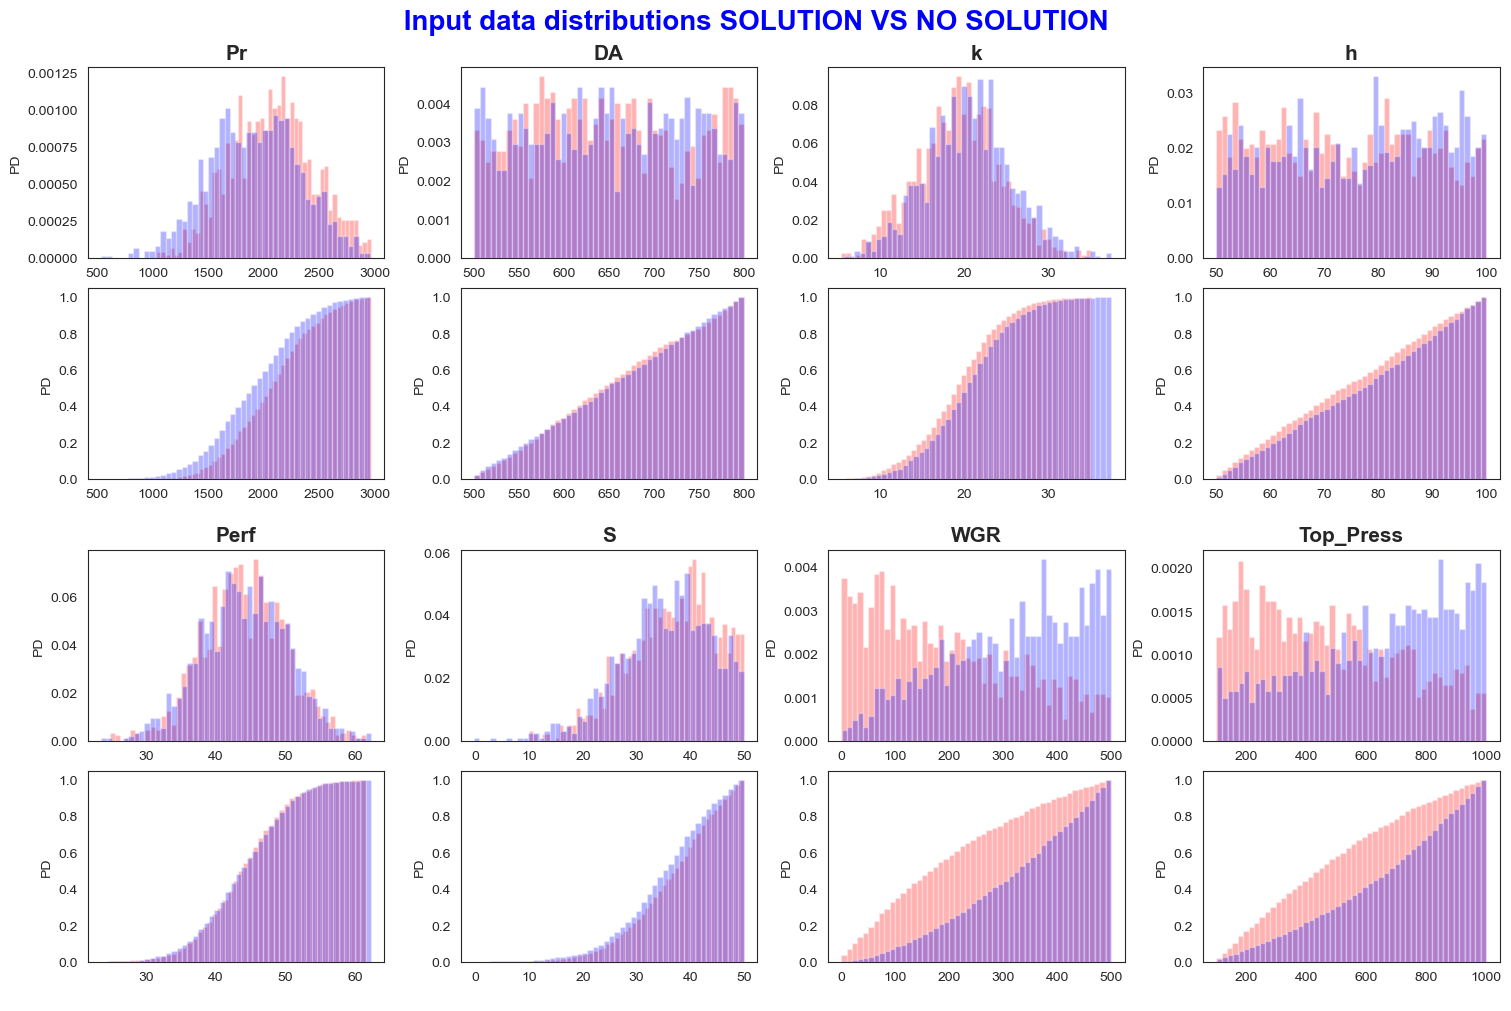

In [17]:
my_Func.Plot_Dist_Cum_Inputs(df_Input_sol,df_Input_No_sol,50)

<font color='blue'>
    
# Compare distributions using Two-Sample Kolmogorov-Smirnov test

    
***
</font>

The null hypothesis (H<sub> 0 </sub>)  is that 2 independent samples are drawn from the same continuous distribution.
. <br>
p-value < 0.05: significant difference between the two distributions



In [18]:
# Create DataFrame to save KS results
df_KS_test = pd.DataFrame(columns = ['Variable Name', 'Statistic', 'p value', 'Result'])

col_names_Inputs_L = df_Input_sol.columns.tolist() # -> Get Column names

for ii in range(8):
    test_vals = stats.ks_2samp(df_Input_sol[col_names_Inputs_L[ii]],df_Input_No_sol[col_names_Inputs_L[ii]])

    print(col_names_Inputs_L[ii], ' = ', test_vals)
    
    a = col_names_Inputs_L[ii]
    b = round(test_vals[0],4)
    cx = round(test_vals[1],6)
    
    if cx < 0.05:
        d = 'H0 rejected, Significant difference'
    else:
        d = 'H0 not rejected'
        
    df_KS_test.loc[len(df_KS_test.index)] = [a,b,cx,d]
    
df_KS_test

def highlight(s):
    if s.Result != 'H0 not rejected':
        return ['background-color: yellow'] * len(s)
    else:
        return ['background-color: white'] * len(s)

df_KS_test.style.apply(highlight, axis=1)

Pr  =  KstestResult(statistic=0.16202252138063536, pvalue=1.6690734521754947e-14, statistic_location=1735.0, statistic_sign=-1)
DA  =  KstestResult(statistic=0.032954863844378325, pvalue=0.5046531516605804, statistic_location=707.4, statistic_sign=1)
k  =  KstestResult(statistic=0.10619671518725568, pvalue=1.7916690367547045e-06, statistic_location=20.4, statistic_sign=1)
h  =  KstestResult(statistic=0.06981494576456618, pvalue=0.004790025057235769, statistic_location=78.6, statistic_sign=1)
Perf  =  KstestResult(statistic=0.02258275406598978, pvalue=0.9036489857995293, statistic_location=47.4, statistic_sign=1)
S  =  KstestResult(statistic=0.08408360128617363, pvalue=0.0003200658223977023, statistic_location=39.8, statistic_sign=-1)
WGR  =  KstestResult(statistic=0.3633847446998706, pvalue=2.219340653636388e-72, statistic_location=232.8, statistic_sign=1)
Top_Press  =  KstestResult(statistic=0.2911181972221852, pvalue=3.040853506719524e-46, statistic_location=582.4, statistic_sign=1)


,Variable Name,Statistic,p value,Result
0,Pr,0.162000,0.000000,"H0 rejected, Significant difference"
1,DA,0.033000,0.504653,H0 not rejected
2,k,0.106200,0.000002,"H0 rejected, Significant difference"
3,h,0.069800,0.004790,"H0 rejected, Significant difference"
4,Perf,0.022600,0.903649,H0 not rejected
5,S,0.084100,0.000320,"H0 rejected, Significant difference"
6,WGR,0.363400,0.000000,"H0 rejected, Significant difference"
7,Top_Press,0.291100,0.000000,"H0 rejected, Significant difference"


<font color='blue'>
    
## 8. Create cross-plots input vs solutions

***
</font>



['Pr', 'DA', 'k', 'h', 'Perf', 'S', 'WGR', 'Top_Press', 'VLP_Corr', 'VLP_Corr_Name', 'Choke', 'Sol_Gas', 'FBHP', 'Sol_WHP', 'Sol_Water']


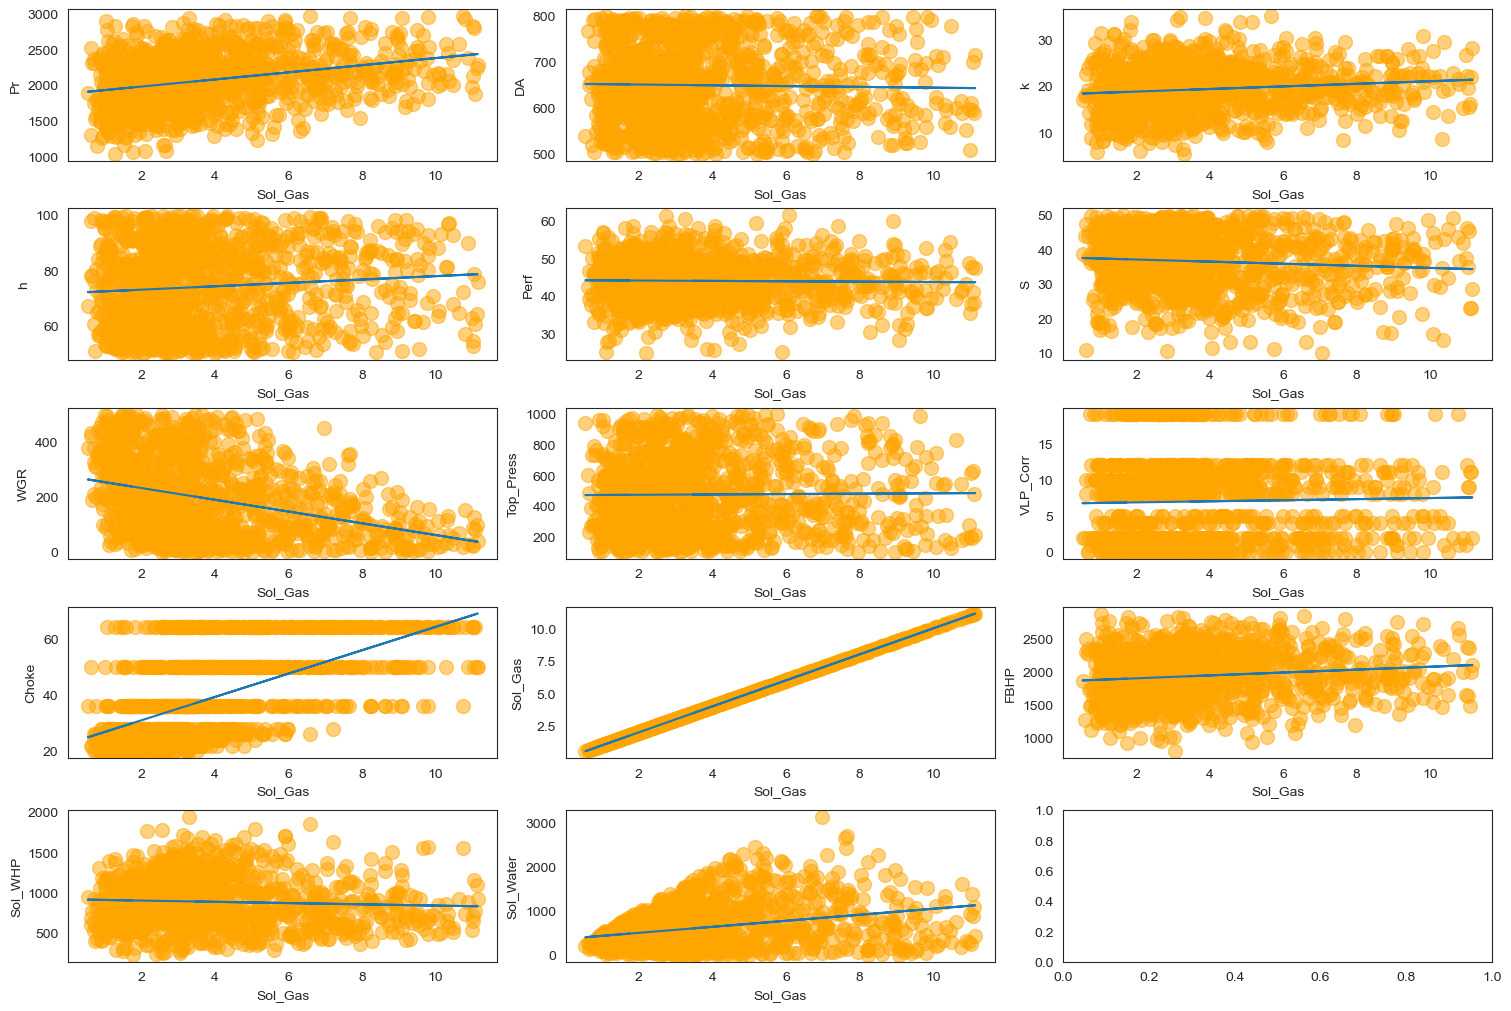

In [19]:
#Create_Cross_Plots_Input_vs_Sol(df_Input_All,'Sol_Gas', 'green',100)
my_Func.Create_Cross_Plots_Input_vs_Sol(df_Input_sol,'Sol_Gas', 'orange',100)

<font color='blue'>
    
## 9. CALCULATE CORRELATION COEFFICIENTS
***
</font>

## Correlation Matrix

,Sol_Gas,FBHP,Sol_WHP,Sol_Water
Pr,0.299,0.364,0.342,0.289
DA,-0.012,0.006,0.004,-0.011
k,-0.030,-0.100,-0.094,-0.047
h,-0.019,-0.073,-0.080,-0.011
Perf,0.003,0.001,0.003,-0.018
S,0.016,0.054,0.053,0.022
WGR,-0.477,-0.370,-0.468,0.040
Top_Press,-0.223,-0.276,-0.179,-0.264
VLP_Corr,-0.032,-0.076,-0.081,-0.030
Choke,0.554,0.280,0.100,0.556


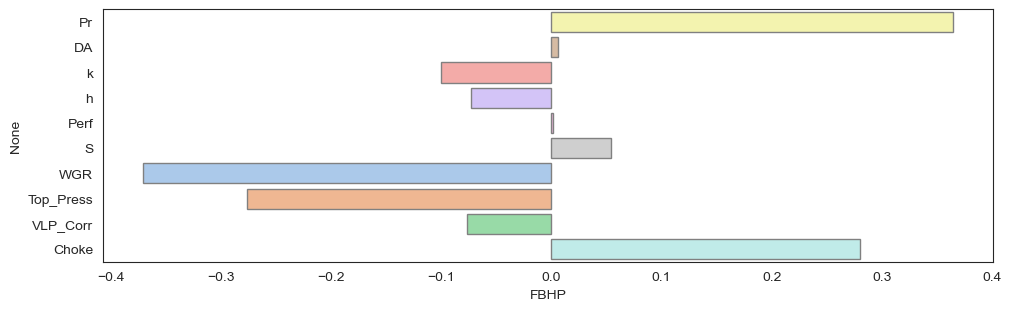

In [20]:
my_Func.Calc_Correlation_coeff(df_Input_All, 'FBHP')

<font color='blue'>
    
## 10. PLOT IPR VS VLP
***
</font>

In [21]:
my_Func.Display_Info_Head_Stats_DF('Info + Values - NO Solutions', df_VLP_IPR, 5)

## Info + Values - NO Solutions

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Iteration     50000 non-null  int64  
 1   Gas Rate      50000 non-null  float64
 2   IPR_Pressure  50000 non-null  float64
 3   VLP_Pressure  50000 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 1.5 MB


,Iteration,Gas Rate,IPR_Pressure,VLP_Pressure
0,0,0.03,2366.95,3008.77
1,0,1.71,2300.63,2281.46
2,0,3.39,2232.78,3246.73
3,0,5.07,2163.24,4610.00
4,0,6.76,2091.84,0.00
5,0,8.44,2018.36,0.00


### Statistics 

,Iteration,Gas Rate,IPR_Pressure,VLP_Pressure
count,50000.00,50000.00,50000.00,50000.00
mean,1249.50,18.34,1307.48,584.52
std,721.69,15.55,588.91,1166.88
min,0.00,0.00,14.92,0.00
10%,249.90,2.25,520.45,0.00
20%,499.80,5.16,797.40,0.00
40%,999.60,11.26,1172.82,0.00
50%,1249.50,14.70,1330.66,0.00
60%,1499.40,18.59,1483.95,0.00
80%,1999.20,29.33,1824.25,1416.44


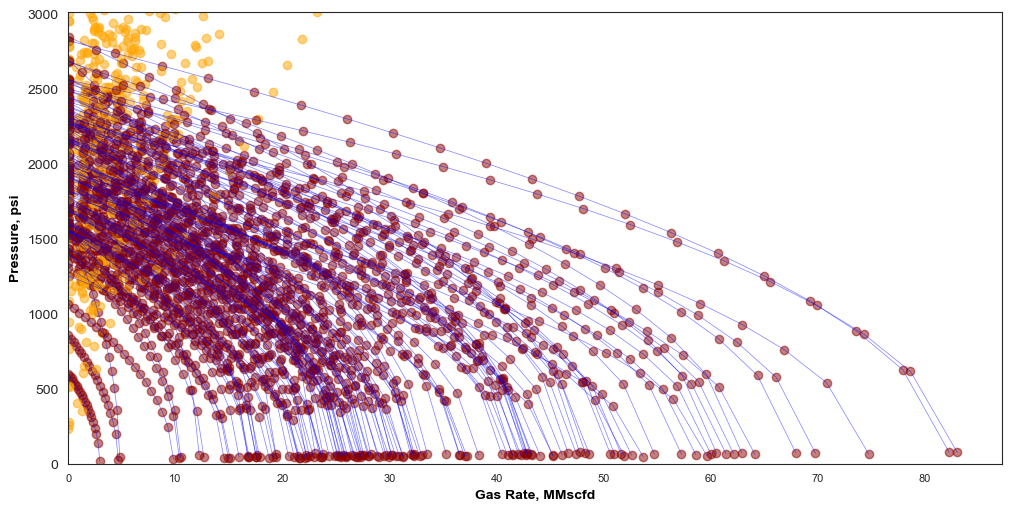

In [22]:
df = df_VLP_IPR.copy()
df.loc[df['VLP_Pressure'] == 0, 'VLP_Pressure'] = np.nan # -> replace zero values with NaN on VLP column

fig, ax_A = plt.subplots(nrows = 1, ncols=1, figsize=(10,5), layout ='constrained')

i = 0
while not i > df.Iteration.count():
    df_i = df[df['Iteration'] == i] # -> filter DataFrame based on iteration
    
    ax_A.scatter(df_i['Gas Rate'], df_i['VLP_Pressure'], c='orange', label='f', alpha=0.5)

    ax_A.plot(df_i['Gas Rate'], df_i['IPR_Pressure'], color='blue', linestyle='-', linewidth=0.5, markersize=6, alpha=0.5)
    ax_A.scatter(df_i['Gas Rate'], df_i['IPR_Pressure'], c='darkred', label='f', alpha=0.5)
    
    
    i = i + 20

ax_A.set_xlabel('Gas Rate, MMscfd', color='black', weight='bold')
ax_A.set_ylabel('Pressure, psi', color='black', weight='bold')
ax_A.tick_params(axis='x', labelsize=8)
ax_A.set_ylim(bottom = 0), ax_A.set_xlim(left = 0);
ax_A.set_ylim(top=df.IPR_Pressure.max()+50);

#### Display VLP vs IPR, distributions and density map

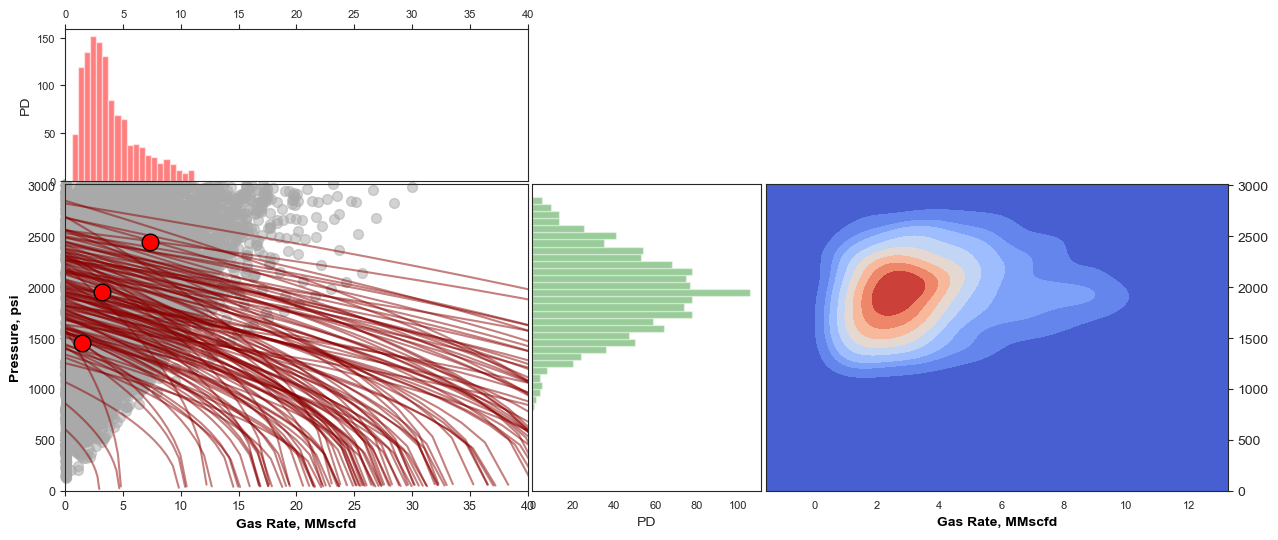

In [25]:
# -> DataFrame VLP and IPR, DataFrame Input, X axis max value
my_Func.Create_Plot_VLP_vs_IPR(df_VLP_IPR,df_Input_sol,40)

<div class="alert alert-success">
<font color='blue'>
    
# CREATE POWERPOINT PRESENTATION

***
</font>
</div>


In [ ]:
from pptx import Presentation
X = Presentation()

In [ ]:
Layout = X.slide_layouts[0] 
first_slide = X.slides.add_slide(Layout) # Adding first slide
first_slide.shapes.title.text = "Creating a powerpoint using Python"

first_slide.placeholders[1].text = "Created by Tutorialpoints"
X.save("First_presentation.pptx")